# 🍜 VNFood — Hierarchical Classification (Group → Sub-class)

Train **1 + 8 models** for hierarchical Vietnamese food classification:
1. **EfficientNet-B0** → classify image into 1 of 8 food groups
2. **8 × EfficientNet-B2** → each group has its own fine-grained classifier

### Pipeline at inference:
`Image → B0 (group) → B2_group (sub-class) → final class name`

## 1. Setup & Imports

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from collections import Counter, OrderedDict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torch.optim.lr_scheduler import CosineAnnealingLR

import torchvision
import torchvision.transforms as transforms
from torchvision import models

from sklearn.metrics import classification_report
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Using device: cuda
GPU: Tesla T4
Memory: 15.6 GB


## 2. Configuration & Group Definitions

In [2]:
# ─── PATHS ───────────────────────────────────────────────────────────────────
DATA_DIR = Path('/kaggle/input/datasets/meowluvmatcha/vnfood-30-100/vnfood_combined_dataset')
OUTPUT_DIR = Path('/kaggle/working')
OUTPUT_DIR.mkdir(exist_ok=True)

# ─── TRAINING HYPERPARAMS ────────────────────────────────────────────────────
BATCH_SIZE    = 32
NUM_WORKERS   = 2
DROPOUT       = 0.3
WEIGHT_DECAY  = 1e-4
LABEL_SMOOTHING = 0.1

# Phase epochs for Group Classifier (EfficientNet-B0)
GROUP_PHASE1_EPOCHS = 5
GROUP_PHASE1_LR     = 1e-3
GROUP_PHASE2_EPOCHS = 10
GROUP_PHASE2_LR     = 1e-4
GROUP_PHASE3_EPOCHS = 15
GROUP_PHASE3_LR     = 5e-5

# Phase epochs for Sub-class Classifiers (EfficientNet-B2)
SUB_PHASE1_EPOCHS = 5
SUB_PHASE1_LR     = 1e-3
SUB_PHASE2_EPOCHS = 10
SUB_PHASE2_LR     = 1e-4
SUB_PHASE3_EPOCHS = 15
SUB_PHASE3_LR     = 5e-5

# Image sizes
GROUP_IMG_SIZE = 224   # EfficientNet-B0
SUB_IMG_SIZE   = 260   # EfficientNet-B2

print('Config loaded ✓')

Config loaded ✓


## 3. Define 8 Food Groups

In [3]:
# ─── GROUP DEFINITIONS ────────────────────────────────────────────────────────
# Note: banh-canh appears in BOTH Group 1 and Group 2 (shared class)
# Some classes appear in multiple groups (e.g. ca-muoi-xoi, bo-kho)

GROUP_CLASSES = OrderedDict({
    'BANH': [
        'banh-bao', 'banh-beo', 'banh-bo', 'banh-bot-loc', 'banh-can',
        'banh-canh', 'banh-chung', 'banh-cong', 'banh-cuon', 'banh-da-cua',
        'banh-da-lon', 'banh-duc', 'banh-gai', 'banh-giay', 'banh-gio',
        'banh-hoi', 'banh-khot', 'banh-la', 'banh-mi', 'banh-mi-chao',
        'banh-pia', 'banh-tai-heo', 'banh-tet', 'banh-tieu',
        'banh-tom-ho-tay', 'banh-trang-nuong', 'banh-troi-nuoc',
        'banh-trung-thu', 'banh-u', 'banh-xeo', 'cao-lau',
    ],
    'BUN_PHO': [
        'pho', 'bun-bo-hue', 'bun-cha', 'bun-cha-ca',
        'bun-dau-mam-tom', 'bun-mam', 'bun-rieu', 'bun-thit-nuong',
        'hu-tieu', 'mi-quang', 'mi-xao-gion', 'nui-xao', 'nam-pia',
        'banh-canh',
    ],
    'COM': [
        'com-chay-cha-bong', 'com-chien', 'com-ga-xoi-mo',
        'com-lam', 'com-rang-dua-bo', 'com-tam',
    ],
    'MON_KHO_NUONG': [
        'bo-kho', 'bo-la-lot', 'bo-luc-lac', 'bo-ne', 'bo-nuong-la-lot',
        'ca-kho-to', 'ca-loc-nuong', 'ca-muoi-xoi', 'ca-sot-ca-chua',
        'ga-chien-nuoc-mam', 'kho-muc-nuong', 'kho-quet', 'lap-xuong',
        'luon-xao-xa-ot', 'muc-nhoi-thit', 'rau-muong-xao', 'thit-kho-tau',
    ],
    'CANH_CHAO': [
        'canh-bi-do', 'canh-chua', 'canh-cua', 'canh-kho-hoa',
        'canh-khoai-tim', 'ca-ri-ga', 'chao-long', 'chao-vit',
        'sup-cua', 'bo-kho', 'luon-om-chuoi-dau',
    ],
    'XOI': [
        'xoi-gac', 'xoi-nep-than', 'xoi-xeo',
    ],
    'GOI_CUON': [
        'goi-ca-chich', 'goi-cuon', 'nem-chua', 'nem-nuong-nha-trang',
        'cha-com', 'cha-lui',
    ],
    'DAC_BIET': [
        'baba-nau-chuoi-dau', 'ca-muoi-xoi', 'cha-ca-la-vong',
        'cua-hap-bia', 'cut-lon-xao-me', 'ga-hap-la-chanh', 'khau-nhuc',
        'mam-chung', 'mam-tep-chung-thit', 'oc-buou-hap', 'oc-huong-xao',
        'oc-len-xao-dua', 'tau-hu-nhoi-thit', 'tau-hu-non', 'thit-dong',
        'thit-trau-gac-bep', 'tiet-canh', 'trung-vit-lon',
    ],
})

NUM_GROUPS = len(GROUP_CLASSES)
GROUP_NAMES = list(GROUP_CLASSES.keys())
group_to_idx = {g: i for i, g in enumerate(GROUP_NAMES)}

# Build reverse map: class_name → group_name (use FIRST group if duplicated)
class_to_group = {}
for gname, cls_list in GROUP_CLASSES.items():
    for cls in cls_list:
        if cls not in class_to_group:
            class_to_group[cls] = gname

print(f'Number of groups: {NUM_GROUPS}')
for gname, cls_list in GROUP_CLASSES.items():
    print(f'  {gname:20s}: {len(cls_list)} classes')
print(f'\nTotal unique classes across all groups: {len(class_to_group)}')

Number of groups: 8
  BANH                : 31 classes
  BUN_PHO             : 14 classes
  COM                 : 6 classes
  MON_KHO_NUONG       : 17 classes
  CANH_CHAO           : 11 classes
  XOI                 : 3 classes
  GOI_CUON            : 6 classes
  DAC_BIET            : 18 classes

Total unique classes across all groups: 103


## 4. Explore & Load Dataset

In [4]:
# ── Auto-detect train/val split ─────────────────────────────────────────────
def find_split_dirs(root: Path):
    for t in ['train', 'Train', 'training']:
        if (root / t).exists():
            train_dir = root / t
            for v in ['val', 'valid', 'validation', 'test']:
                if (root / v).exists():
                    return train_dir, root / v
            return train_dir, None
    return root, None

TRAIN_DIR, VAL_DIR = find_split_dirs(DATA_DIR)
print(f'Train dir : {TRAIN_DIR}')
print(f'Val dir   : {VAL_DIR}')

# All 103 original classes
all_class_names = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
all_class_to_idx = {c: i for i, c in enumerate(all_class_names)}
print(f'Total classes found on disk: {len(all_class_names)}')

# Verify all group classes exist in dataset
missing = [c for c in class_to_group if c not in all_class_to_idx]
if missing:
    print(f'WARNING: classes in groups but not on disk: {missing}')
else:
    print('All group classes found on disk ✓')

Train dir : /kaggle/input/datasets/meowluvmatcha/vnfood-30-100/vnfood_combined_dataset/train
Val dir   : /kaggle/input/datasets/meowluvmatcha/vnfood-30-100/vnfood_combined_dataset/val
Total classes found on disk: 103
All group classes found on disk ✓


## 5. Transforms

In [5]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

def get_transforms(img_size):
    train_tf = transforms.Compose([
        transforms.Resize((img_size + 20, img_size + 20)),
        transforms.RandomCrop(img_size),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.1),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
        transforms.RandomGrayscale(p=0.02),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD),
        transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),
    ])
    val_tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD),
    ])
    return train_tf, val_tf

print('Transforms factory defined ✓')

Transforms factory defined ✓


## 6. Dataset Classes

In [6]:
class FoodDataset(Dataset):
    """Generic dataset that loads images from class-name subdirectories."""
    def __init__(self, root_dir, class_to_idx, transform=None,
                 extensions=('.jpg', '.jpeg', '.png', '.webp')):
        self.root_dir     = Path(root_dir)
        self.class_to_idx = class_to_idx
        self.transform    = transform
        self.samples      = []

        for cls, idx in class_to_idx.items():
            cls_dir = self.root_dir / cls
            if not cls_dir.exists():
                continue
            for f in cls_dir.iterdir():
                if f.suffix.lower() in extensions:
                    self.samples.append((str(f), idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            img = Image.open(path).convert('RGB')
        except Exception:
            img = Image.new('RGB', (260, 260))
        if self.transform:
            img = self.transform(img)
        return img, label


class GroupLabelDataset(Dataset):
    """Wraps a FoodDataset but returns GROUP labels instead of class labels."""
    def __init__(self, root_dir, class_names, class_to_group_map, group_to_idx_map,
                 transform=None, extensions=('.jpg', '.jpeg', '.png', '.webp')):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.samples = []

        for cls in class_names:
            if cls not in class_to_group_map:
                continue
            gname = class_to_group_map[cls]
            gidx  = group_to_idx_map[gname]
            cls_dir = self.root_dir / cls
            if not cls_dir.exists():
                continue
            for f in cls_dir.iterdir():
                if f.suffix.lower() in extensions:
                    self.samples.append((str(f), gidx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            img = Image.open(path).convert('RGB')
        except Exception:
            img = Image.new('RGB', (224, 224))
        if self.transform:
            img = self.transform(img)
        return img, label

print('Dataset classes defined ✓')

Dataset classes defined ✓


## 7. Model Builders & Training Utilities

In [7]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights


def build_group_model(num_classes: int, dropout: float = 0.3) -> nn.Module:
    """EfficientNet-B0 for group classification."""
    model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout, inplace=True),
        nn.Linear(in_features, num_classes)
    )
    return model


def build_sub_model(num_classes: int, dropout: float = 0.3) -> nn.Module:
    """EfficientNet-B2 for sub-class classification within a group."""
    model = efficientnet_b2(weights=EfficientNet_B2_Weights.IMAGENET1K_V1)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout, inplace=True),
        nn.Linear(in_features, num_classes)
    )
    return model


def freeze_backbone(model):
    for name, param in model.named_parameters():
        if 'classifier' not in name:
            param.requires_grad = False

def unfreeze_top_blocks(model, num_blocks=3):
    total_blocks = len([n for n in model.features]) - 1
    unfreeze_from = total_blocks - num_blocks
    for name, param in model.named_parameters():
        block_match = False
        for i in range(unfreeze_from, total_blocks + 1):
            if f'features.{i}' in name:
                block_match = True
        if block_match or 'classifier' in name:
            param.requires_grad = True

def unfreeze_all(model):
    for param in model.parameters():
        param.requires_grad = True

def count_trainable(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    return f'{trainable:,} / {total:,} ({100*trainable/total:.1f}%)'


class AverageMeter:
    def __init__(self):
        self.reset()
    def reset(self):
        self.val = self.avg = self.sum = self.count = 0
    def update(self, val, n=1):
        self.val   = val
        self.sum  += val * n
        self.count += n
        self.avg   = self.sum / self.count


def train_epoch(model, loader, criterion, optimizer, scaler, num_classes):
    model.train()
    loss_m, top1_m = AverageMeter(), AverageMeter()
    pbar = tqdm(loader, desc='  Train', leave=False)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with torch.cuda.amp.autocast():
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        bs = imgs.size(0)
        top1 = (outputs.argmax(1) == labels).float().mean().item()
        loss_m.update(loss.item(), bs)
        top1_m.update(top1, bs)
        pbar.set_postfix(loss=f'{loss_m.avg:.4f}', top1=f'{top1_m.avg:.3f}')
    return loss_m.avg, top1_m.avg


@torch.no_grad()
def val_epoch(model, loader, criterion, num_classes):
    model.eval()
    loss_m, top1_m = AverageMeter(), AverageMeter()
    pbar = tqdm(loader, desc='  Val  ', leave=False)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with torch.cuda.amp.autocast():
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        bs = imgs.size(0)
        top1 = (outputs.argmax(1) == labels).float().mean().item()
        loss_m.update(loss.item(), bs)
        top1_m.update(top1, bs)
        pbar.set_postfix(loss=f'{loss_m.avg:.4f}', top1=f'{top1_m.avg:.3f}')
    return loss_m.avg, top1_m.avg


def run_phase(phase_name, num_epochs, lr, model, train_loader, val_loader,
              criterion, scaler, num_classes, best_val_acc=0.0, save_path=None, patience=5):
    """Train one phase, return best_val_acc."""
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                            lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=lr * 0.01)
    no_improve = 0

    for epoch in range(1, num_epochs + 1):
        print(f'  [{phase_name}] Epoch {epoch}/{num_epochs}')
        tr_loss, tr_top1 = train_epoch(model, train_loader, criterion, optimizer, scaler, num_classes)
        vl_loss, vl_top1 = val_epoch(model, val_loader, criterion, num_classes)
        scheduler.step()
        print(f'    Train loss={tr_loss:.4f} top1={tr_top1:.4f}')
        print(f'    Val   loss={vl_loss:.4f} top1={vl_top1:.4f}')

        if vl_top1 > best_val_acc:
            best_val_acc = vl_top1
            if save_path:
                torch.save({'model_state': model.state_dict(), 'val_acc': best_val_acc}, save_path)
            print(f'    ✅ New best val_acc={best_val_acc:.4f}')
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'    ⏹ Early stopping')
                break
    return best_val_acc


def train_full_pipeline(model, train_loader, val_loader, num_classes, save_path,
                        p1_epochs, p1_lr, p2_epochs, p2_lr, p3_epochs, p3_lr):
    """Run 3-phase training: head-only → top blocks → full fine-tune."""
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    scaler = torch.cuda.amp.GradScaler()
    best_acc = 0.0

    # Phase 1 — head only
    freeze_backbone(model)
    print(f'  Phase 1 — Trainable: {count_trainable(model)}')
    best_acc = run_phase('P1-head', p1_epochs, p1_lr, model, train_loader, val_loader,
                         criterion, scaler, num_classes, best_acc, save_path)

    # Phase 2 — top 3 blocks
    unfreeze_top_blocks(model, num_blocks=3)
    print(f'  Phase 2 — Trainable: {count_trainable(model)}')
    best_acc = run_phase('P2-top3', p2_epochs, p2_lr, model, train_loader, val_loader,
                         criterion, scaler, num_classes, best_acc, save_path)

    # Phase 3 — full fine-tune
    unfreeze_all(model)
    print(f'  Phase 3 — Trainable: {count_trainable(model)}')
    best_acc = run_phase('P3-full', p3_epochs, p3_lr, model, train_loader, val_loader,
                         criterion, scaler, num_classes, best_acc, save_path, patience=7)

    print(f'  🏆 Best val accuracy: {best_acc*100:.2f}%')
    return best_acc

print('Training utilities defined ✓')

Training utilities defined ✓


## 8. Train Group Classifier (EfficientNet-B0 → 8 groups)

In [8]:
print('='*60)
print('  TRAINING GROUP CLASSIFIER (EfficientNet-B0 → 8 groups)')
print('='*60)

group_train_tf, group_val_tf = get_transforms(GROUP_IMG_SIZE)

# Build group-level datasets
group_train_ds = GroupLabelDataset(
    TRAIN_DIR, list(class_to_group.keys()), class_to_group, group_to_idx,
    transform=group_train_tf
)

if VAL_DIR is not None:
    group_val_ds = GroupLabelDataset(
        VAL_DIR, list(class_to_group.keys()), class_to_group, group_to_idx,
        transform=group_val_tf
    )
else:
    from torch.utils.data import random_split
    val_size = int(0.2 * len(group_train_ds))
    train_size = len(group_train_ds) - val_size
    group_train_ds, group_val_ds = random_split(
        group_train_ds, [train_size, val_size],
        generator=torch.Generator().manual_seed(SEED)
    )

group_train_loader = DataLoader(group_train_ds, batch_size=BATCH_SIZE, shuffle=True,
                                 num_workers=NUM_WORKERS, pin_memory=True)
group_val_loader   = DataLoader(group_val_ds, batch_size=BATCH_SIZE, shuffle=False,
                                 num_workers=NUM_WORKERS, pin_memory=True)

print(f'Group train samples: {len(group_train_ds)}')
print(f'Group val samples  : {len(group_val_ds)}')

# Build and train
group_model = build_group_model(NUM_GROUPS, DROPOUT).to(DEVICE)
GROUP_MODEL_PATH = OUTPUT_DIR / 'best_group_effb0.pth'

group_best_acc = train_full_pipeline(
    group_model, group_train_loader, group_val_loader,
    NUM_GROUPS, GROUP_MODEL_PATH,
    GROUP_PHASE1_EPOCHS, GROUP_PHASE1_LR,
    GROUP_PHASE2_EPOCHS, GROUP_PHASE2_LR,
    GROUP_PHASE3_EPOCHS, GROUP_PHASE3_LR,
)

# Save final checkpoint with metadata
group_ckpt = {
    'model_state': group_model.state_dict(),
    'group_names': GROUP_NAMES,
    'group_to_idx': group_to_idx,
    'num_groups': NUM_GROUPS,
    'img_size': GROUP_IMG_SIZE,
    'best_val_acc': group_best_acc,
}
torch.save(group_ckpt, OUTPUT_DIR / 'group_effb0_final.pth')
print(f'\nGroup model saved ✓')

  TRAINING GROUP CLASSIFIER (EfficientNet-B0 → 8 groups)
Group train samples: 34456
Group val samples  : 7383
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 188MB/s]


  Phase 1 — Trainable: 10,248 / 4,017,796 (0.3%)
  [P1-head] Epoch 1/5


  Train:   0%|          | 0/1077 [00:00<?, ?it/s]

  Val  :   0%|          | 0/231 [00:00<?, ?it/s]

...

  Val  :   0%|          | 0/231 [00:00<?, ?it/s]

    Train loss=0.5739 top1=0.9702
    Val   loss=0.6697 top1=0.9248
    ✅ New best val_acc=0.9248
  [P3-full] Epoch 15/15


  Train:   0%|          | 0/1077 [00:00<?, ?it/s]

  Val  :   0%|          | 0/231 [00:00<?, ?it/s]

    Train loss=0.5722 top1=0.9707
    Val   loss=0.6683 top1=0.9248
  🏆 Best val accuracy: 92.48%

Group model saved ✓


## 9. Train Sub-class Classifiers (8 × EfficientNet-B2)

In [9]:
print('='*60)
print('  TRAINING SUB-CLASS CLASSIFIERS (8 × EfficientNet-B2)')
print('='*60)

sub_train_tf, sub_val_tf = get_transforms(SUB_IMG_SIZE)
sub_results = {}

for group_name, group_classes in GROUP_CLASSES.items():
    print(f'\n{"─"*60}')
    print(f'  Group: {group_name}  ({len(group_classes)} classes)')
    print(f'{"─"*60}')

    # Build class_to_idx for this group (local indices 0..N-1)
    sorted_classes = sorted(group_classes)
    local_class_to_idx = {c: i for i, c in enumerate(sorted_classes)}
    num_local = len(sorted_classes)

    # Build datasets
    sub_train_ds = FoodDataset(TRAIN_DIR, local_class_to_idx, transform=sub_train_tf)

    if VAL_DIR is not None:
        sub_val_ds = FoodDataset(VAL_DIR, local_class_to_idx, transform=sub_val_tf)
    else:
        from torch.utils.data import random_split
        val_sz = int(0.2 * len(sub_train_ds))
        tr_sz = len(sub_train_ds) - val_sz
        sub_train_ds, sub_val_ds = random_split(
            sub_train_ds, [tr_sz, val_sz],
            generator=torch.Generator().manual_seed(SEED)
        )

    if len(sub_train_ds) == 0:
        print(f'  ⚠️ No training data for {group_name}, skipping!')
        continue

    sub_train_loader = DataLoader(sub_train_ds, batch_size=BATCH_SIZE, shuffle=True,
                                   num_workers=NUM_WORKERS, pin_memory=True)
    sub_val_loader   = DataLoader(sub_val_ds, batch_size=BATCH_SIZE, shuffle=False,
                                   num_workers=NUM_WORKERS, pin_memory=True)

    print(f'  Train: {len(sub_train_ds)} | Val: {len(sub_val_ds)} | Classes: {num_local}')

    # Build and train model
    sub_model = build_sub_model(num_local, DROPOUT).to(DEVICE)
    save_path = OUTPUT_DIR / f'best_sub_{group_name}_effb2.pth'

    best_acc = train_full_pipeline(
        sub_model, sub_train_loader, sub_val_loader,
        num_local, save_path,
        SUB_PHASE1_EPOCHS, SUB_PHASE1_LR,
        SUB_PHASE2_EPOCHS, SUB_PHASE2_LR,
        SUB_PHASE3_EPOCHS, SUB_PHASE3_LR,
    )

    # Save final with metadata
    sub_ckpt = {
        'model_state': sub_model.state_dict(),
        'group_name': group_name,
        'class_names': sorted_classes,
        'class_to_idx': local_class_to_idx,
        'num_classes': num_local,
        'img_size': SUB_IMG_SIZE,
        'best_val_acc': best_acc,
    }
    torch.save(sub_ckpt, OUTPUT_DIR / f'sub_{group_name}_effb2_final.pth')

    sub_results[group_name] = {'num_classes': num_local, 'best_acc': best_acc}

    # Free GPU memory
    del sub_model
    torch.cuda.empty_cache()

print(f'\n{"="*60}')
print('  ALL SUB-CLASS MODELS TRAINED')
print(f'{"="*60}')
for gname, res in sub_results.items():
    print(f'  {gname:20s}: {res["num_classes"]:3d} classes | val_acc = {res["best_acc"]*100:.2f}%')

  TRAINING SUB-CLASS CLASSIFIERS (8 × EfficientNet-B2)

────────────────────────────────────────────────────────────
  Group: BANH  (31 classes)
────────────────────────────────────────────────────────────
  Train: 14255 | Val: 3051 | Classes: 31
Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 178MB/s]


  Phase 1 — Trainable: 43,679 / 7,744,673 (0.6%)
  [P1-head] Epoch 1/5


  Train:   0%|          | 0/446 [00:00<?, ?it/s]

  Val  :   0%|          | 0/96 [00:00<?, ?it/s]

...

  Val  :   0%|          | 0/17 [00:00<?, ?it/s]

    Train loss=0.6497 top1=0.9947
    Val   loss=0.7795 top1=0.9389
  [P3-full] Epoch 13/15


  Train:   0%|          | 0/77 [00:00<?, ?it/s]

  Val  :   0%|          | 0/17 [00:00<?, ?it/s]

    Train loss=0.6499 top1=0.9938
    Val   loss=0.7729 top1=0.9370
    ⏹ Early stopping
  🏆 Best val accuracy: 94.47%

  ALL SUB-CLASS MODELS TRAINED
  BANH                :  31 classes | val_acc = 94.59%
  BUN_PHO             :  14 classes | val_acc = 90.35%
  COM                 :   6 classes | val_acc = 97.36%
  MON_KHO_NUONG       :  17 classes | val_acc = 93.51%
  CANH_CHAO           :  11 classes | val_acc = 95.10%
  XOI                 :   3 classes | val_acc = 98.88%
  GOI_CUON            :   6 classes | val_acc = 95.49%
  DAC_BIET            :  18 classes | val_acc = 94.47%


## 10. Hierarchical Inference Pipeline


True label : goi-cuon
Predicted  : GOI_CUON (76.0%) → goi-cuon (81.0%)


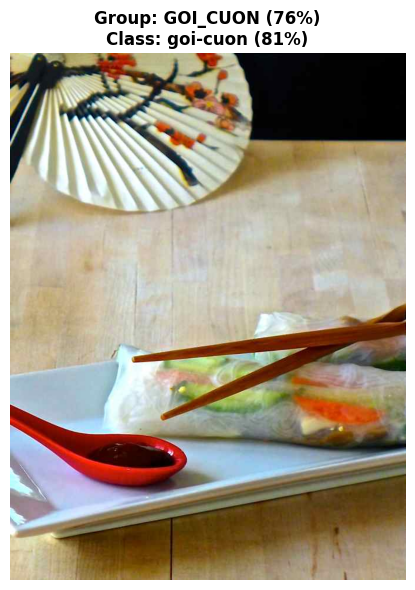

In [10]:
def load_all_models(output_dir):
    """Load group model + all sub-class models for inference."""
    # Load group model
    group_ckpt = torch.load(output_dir / 'group_effb0_final.pth', map_location=DEVICE)
    group_model = build_group_model(group_ckpt['num_groups']).to(DEVICE)
    group_model.load_state_dict(group_ckpt['model_state'])
    group_model.eval()

    # Load sub models
    sub_models = {}
    for gname in group_ckpt['group_names']:
        fpath = output_dir / f'sub_{gname}_effb2_final.pth'
        if not fpath.exists():
            print(f'Warning: missing sub-model for {gname}')
            continue
        sub_ckpt = torch.load(fpath, map_location=DEVICE)
        sub_model = build_sub_model(sub_ckpt['num_classes']).to(DEVICE)
        sub_model.load_state_dict(sub_ckpt['model_state'])
        sub_model.eval()
        sub_models[gname] = {
            'model': sub_model,
            'class_names': sub_ckpt['class_names'],
        }

    return group_model, group_ckpt, sub_models


@torch.no_grad()
def predict_hierarchical(image_path, group_model, group_ckpt, sub_models):
    """
    2-stage prediction:
      Stage 1: EfficientNet-B0 → predict group
      Stage 2: EfficientNet-B2 (group-specific) → predict sub-class
    """
    img = Image.open(image_path).convert('RGB')

    # Stage 1: Group prediction
    _, group_val_tf = get_transforms(group_ckpt['img_size'])
    group_tensor = group_val_tf(img).unsqueeze(0).to(DEVICE)
    group_output = group_model(group_tensor)
    group_probs = torch.softmax(group_output, dim=1).squeeze().cpu().numpy()
    group_idx = group_probs.argmax()
    group_name = group_ckpt['group_names'][group_idx]
    group_conf = group_probs[group_idx]

    # Stage 2: Sub-class prediction
    if group_name not in sub_models:
        return group_name, group_conf, 'unknown', 0.0

    sub_info = sub_models[group_name]
    _, sub_val_tf = get_transforms(SUB_IMG_SIZE)
    sub_tensor = sub_val_tf(img).unsqueeze(0).to(DEVICE)
    sub_output = sub_info['model'](sub_tensor)
    sub_probs = torch.softmax(sub_output, dim=1).squeeze().cpu().numpy()
    sub_idx = sub_probs.argmax()
    sub_name = sub_info['class_names'][sub_idx]
    sub_conf = sub_probs[sub_idx]

    return group_name, group_conf, sub_name, sub_conf


# Load and test
group_model_inf, group_ckpt_inf, sub_models_inf = load_all_models(OUTPUT_DIR)

# Test on random image
sample_cls = random.choice(list(class_to_group.keys()))
sample_dir = (VAL_DIR or TRAIN_DIR) / sample_cls
sample_imgs = list(sample_dir.glob('*'))
if sample_imgs:
    test_img = str(random.choice(sample_imgs))
    gname, gconf, sname, sconf = predict_hierarchical(
        test_img, group_model_inf, group_ckpt_inf, sub_models_inf
    )
    print(f'\nTrue label : {sample_cls}')
    print(f'Predicted  : {gname} ({gconf:.1%}) → {sname} ({sconf:.1%})')

    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.imshow(Image.open(test_img))
    ax.set_title(f'Group: {gname} ({gconf:.0%})\nClass: {sname} ({sconf:.0%})', fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

## 11. Summary & Output Files

In [11]:
print('='*60)
print('         TRAINING COMPLETE — ALL MODELS')
print('='*60)
print(f'\n  Group classifier (EfficientNet-B0):')
print(f'    Best val acc: {group_best_acc*100:.2f}%')
print(f'    Saved: {GROUP_MODEL_PATH.name}')
print()
print(f'  Sub-class classifiers (EfficientNet-B2):')
for gname, res in sub_results.items():
    print(f'    {gname:20s}: {res["best_acc"]*100:.2f}% ({res["num_classes"]} classes)')
print()
print(f'Output directory: {OUTPUT_DIR}')
print()
for f in sorted(OUTPUT_DIR.glob('*.pth')):
    size_mb = f.stat().st_size / 1e6
    print(f'  {f.name:<50s} {size_mb:.1f} MB')
print('='*60)

         TRAINING COMPLETE — ALL MODELS

  Group classifier (EfficientNet-B0):
    Best val acc: 92.48%
    Saved: best_group_effb0.pth

  Sub-class classifiers (EfficientNet-B2):
    BANH                : 94.59% (31 classes)
    BUN_PHO             : 90.35% (14 classes)
    COM                 : 97.36% (6 classes)
    MON_KHO_NUONG       : 93.51% (17 classes)
    CANH_CHAO           : 95.10% (11 classes)
    XOI                 : 98.88% (3 classes)
    GOI_CUON            : 95.49% (6 classes)
    DAC_BIET            : 94.47% (18 classes)

Output directory: /kaggle/working

  best_group_effb0.pth                               16.4 MB
  best_sub_BANH_effb2.pth                            31.4 MB
  best_sub_BUN_PHO_effb2.pth                         31.3 MB
  best_sub_CANH_CHAO_effb2.pth                       31.3 MB
  best_sub_COM_effb2.pth                             31.3 MB
  best_sub_DAC_BIET_effb2.pth                        31.4 MB
  best_sub_GOI_CUON_effb2.pth                        